# SK Model: GD vs AMP Comparative Benchmark
Sweeps N × matrix modes, collects wall time, FLOP estimates, convergence, and energy accuracy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import time
import warnings
from itertools import product as iproduct

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


## 1. Core Algorithms (from source script)

In [2]:
# ── Matrix generators ───────────────────────────────────────────────────────

def generate_sk_matrix(N):
    J = np.random.normal(0.0, 1.0 / np.sqrt(N), size=(N, N))
    J = (J + J.T) / np.sqrt(2)
    np.fill_diagonal(J, 0.0)
    return J

# def generate_structured_matrix(N):
#     hidden = np.random.choice([-1.0, 1.0], size=N)
#     J = np.outer(hidden, hidden) / N
#     np.fill_diagonal(J, 0.0)
#     return J, -0.5 * N

# def generate_hopfield_matrix(N, num_patterns=10):
#     J = np.zeros((N, N))
#     for _ in range(num_patterns):
#         p = np.random.choice([-1.0, 1.0], size=N)
#         J += np.outer(p, p)
#     J /= N
#     np.fill_diagonal(J, 0.0)
#     approx_floor = -0.5 * N * (1 + np.sqrt(num_patterns / N))
#     return J, approx_floor

# ── Energy ──────────────────────────────────────────────────────────────────

def calculate_energy(sigma, J):
    return -0.5 * (sigma @ J @ sigma)

# ── Gradient descent ────────────────────────────────────────────────────────

def gradient_descent_sk(J, num_iterations=200, learning_rate=0.1, convergence_tol=1e-5):
    N = J.shape[0]
    sigma = np.random.uniform(-1.0, 1.0, size=N)
    energy_history = []
    convergence_iter = num_iterations  # default: never converged early
    converged = False

    for i in range(num_iterations):
        gradient = -(J @ sigma)          # O(N^2) matmul
        sigma = sigma - learning_rate * gradient
        sigma = np.clip(sigma, -1.0, 1.0)
        e = calculate_energy(sigma, J)
        energy_history.append(float(e))

        if i > 0 and not converged:
            delta = abs(energy_history[-1] - energy_history[-2])
            if delta < convergence_tol * abs(energy_history[-1] + 1e-12):
                convergence_iter = i + 1
                converged = True

    return sigma, energy_history, convergence_iter

# ── AMP ─────────────────────────────────────────────────────────────────────

def amp_sk(J, m_init, num_iterations=500, damping=0.7):
    N = J.shape[0]
    m = np.copy(m_init)
    m_old = np.zeros(N)
    h = np.zeros(N)
    betas = np.linspace(0.1, 2.5, num_iterations)

    for beta in betas:
        onsager = np.mean(1.0 - m**2)
        h_target = J @ m - beta * onsager * m_old   # O(N^2) matmul
        h = damping * h + (1.0 - damping) * h_target
        m_old = np.copy(m)
        m = np.tanh(beta * h)

    return np.sign(m)

def greedy_quench(sigma, J):
    sigma_opt = np.copy(sigma).astype(float)
    N = len(sigma_opt)
    improved = True
    passes = 0

    while improved:
        improved = False
        local_fields = J @ sigma_opt   # O(N^2) per pass
        frustration = sigma_opt * local_fields
        idx = np.argmin(frustration)
        if frustration[idx] < 0:
            sigma_opt[idx] *= -1
            improved = True
        passes += 1

    return sigma_opt, passes

def get_orthogonal_starts(num_starts, N, scale=0.001):
    random_directions = np.random.normal(size=(N, num_starts))
    Q, _ = np.linalg.qr(random_directions)
    return Q.T[:num_starts] * scale

print('Algorithm definitions ready.')

Algorithm definitions ready.


## 2. FLOP Estimators
Each matrix-vector product costs `2N²` FLOPs (multiply-accumulate).

In [3]:
def flops_gd(N, num_iterations, convergence_iter=None):
    """
    Per iteration: one N×N matvec (2N²) + clip + energy matvec (2N²).
    We count both the gradient matvec and the energy evaluation.
    """
    iters = convergence_iter if convergence_iter is not None else num_iterations
    matvecs_per_iter = 2          # gradient + energy eval
    flops_per_matvec = 2 * N * N  # multiply-accumulate
    return iters * matvecs_per_iter * flops_per_matvec

def flops_amp(N, amp_iters, num_restarts, quench_passes_list):
    """
    AMP: Break down into three components:
    1. Onsager term: mean(1 - m²) ≈ N FLOPs per iteration per restart
    2. Damping: h = damping*h + (1-damping)*h_target ≈ 2N FLOPs per iteration per restart
    3. Matvec: J @ m in h_target ≈ 2N² FLOPs per iteration per restart, plus quench passes
    """
    # Per beta iteration, per restart
    onsager_flops = num_restarts * amp_iters * N
    damping_flops = num_restarts * amp_iters * 2 * N
    
    # Matvec: amp iterations + quench passes
    amp_matvec_flops = num_restarts * amp_iters * (2 * N * N)
    quench_matvec_flops = sum(p * 2 * N * N for p in quench_passes_list)
    matvec_flops = amp_matvec_flops + quench_matvec_flops
    
    total_flops = onsager_flops + damping_flops + matvec_flops
    
    return {
        'onsager': onsager_flops,
        'damping': damping_flops,
        'matvec': matvec_flops,
        'total': total_flops
    }

print('FLOP estimators defined.')

FLOP estimators defined.


## 3. Sweep Configuration

In [4]:
# ── Sizes to sweep ──────────────────────────────────────────────────────
N_VALUES = [50, 100, 250, 500, 1000, 2000, 3000]
# Add 5000/10000 here if you have the patience — each 10k run takes ~minutes.

MODE = 'RANDOM'  # Only RANDOM mode is used; focus on iteration sweeps
HOPFIELD_PATTERNS = 10

# ── Iteration values to sweep ────────────────────────────────────────────────
ITERATION_VALUES = [100, 250, 500, 1000]

# ── Per-algorithm hyperparams (fixed across N for fair comparison) ──────────
GD_LR          = 0.1
GD_CONV_TOL    = 1e-5

AMP_DAMPING    = 0.7
NUM_RESTARTS   = 10       # orthogonal starts (100 in original; reduced for sweep speed)

print(f'Will sweep N={N_VALUES}')
print(f'Iterations: {ITERATION_VALUES}')
print(f'Mode: {MODE}')
print(f'GD & AMP: {ITERATION_VALUES} iters × {NUM_RESTARTS} restarts (AMP)')

Will sweep N=[50, 100, 250, 500, 1000, 2000, 3000]
Iterations: [100, 250, 500, 1000]
Mode: RANDOM
GD & AMP: [100, 250, 500, 1000] iters × 10 restarts (AMP)


## 4. Main Benchmark Loop

In [5]:
records = []
convergence_curves = {}

for N, iterations in iproduct(N_VALUES, ITERATION_VALUES):
    print(f'\n=== N={N}, iterations={iterations} ===')
    J = generate_sk_matrix(N)
    theoretical_limit = -0.763 * N

    # GD benchmark
    t0 = time.time()
    gd_sigma, gd_history, gd_convergence_iter = gradient_descent_sk(
        J,
        num_iterations=iterations,
        learning_rate=GD_LR,
        convergence_tol=GD_CONV_TOL,
    )
    gd_wall = time.time() - t0
    gd_final_energy = float(calculate_energy(gd_sigma, J))
    gd_gap = gd_final_energy - theoretical_limit
    gd_rel_gap_pct = 100.0 * gd_gap / (abs(theoretical_limit) + 1e-12)
    gd_flops = flops_gd(N, iterations, convergence_iter=gd_convergence_iter)
    gd_flops_per_sec = round(gd_flops / (gd_wall + 1e-12))

    # AMP benchmark with multiple restarts and greedy quench
    restarts = get_orthogonal_starts(NUM_RESTARTS, N, scale=0.001)
    amp_best_energy = float('inf')
    amp_cumulative_best = []
    quench_passes = []

    t1 = time.time()
    for restart_idx, m_init in enumerate(restarts, start=1):
        amp_out = amp_sk(J, m_init, num_iterations=iterations, damping=AMP_DAMPING)
        quench_out, passes = greedy_quench(amp_out, J)
        quench_passes.append(passes)

        candidate_energy = float(calculate_energy(quench_out, J))
        if candidate_energy < amp_best_energy:
            amp_best_energy = candidate_energy
        amp_cumulative_best.append(amp_best_energy)

    amp_wall = time.time() - t1
    amp_gap = amp_best_energy - theoretical_limit
    amp_rel_gap_pct = 100.0 * amp_gap / (abs(theoretical_limit) + 1e-12)
    amp_flop_breakdown = flops_amp(N, iterations, NUM_RESTARTS, quench_passes)

    target_energy = amp_best_energy + 0.05 * abs(amp_best_energy)
    amp_conv_restart = next(
        (idx for idx, energy in enumerate(amp_cumulative_best, start=1) if energy <= target_energy),
        NUM_RESTARTS,
    )

    rec = {
        'N': N,
        'iterations': iterations,
        'theoretical_limit': theoretical_limit,
        # GD stats
        'gd_final_energy': gd_final_energy,
        'gd_gap': gd_gap,
        'gd_rel_gap_pct': gd_rel_gap_pct,
        'gd_wall_sec': gd_wall,
        'gd_convergence_iter': gd_convergence_iter,
        'gd_flops': gd_flops,
        'gd_flops_per_sec': gd_flops_per_sec,
        # AMP stats
        'amp_best_energy': amp_best_energy,
        'amp_gap': amp_gap,
        'amp_rel_gap_pct': amp_rel_gap_pct,
        'amp_wall_sec': amp_wall,
        'amp_conv_restart': amp_conv_restart,
        'amp_flops_onsager': amp_flop_breakdown['onsager'],
        'amp_flops_damping': amp_flop_breakdown['damping'],
        'amp_flops_matvec': amp_flop_breakdown['matvec'],
        'amp_total_flops': amp_flop_breakdown['total'],
        'amp_flops_per_sec': round(amp_flop_breakdown['total'] / (amp_wall + 1e-12)),
        'amp_mean_quench_passes': round(np.mean(quench_passes), 2),
        'amp_total_quench_passes': int(np.sum(quench_passes)),
        # Head-to-head
        'winner': 'AMP' if amp_best_energy < gd_final_energy else 'GD',
        'energy_improvement': round(gd_final_energy - amp_best_energy, 4),
        'speedup_gd_over_amp': round(amp_wall / (gd_wall + 1e-12), 3),
    }
    records.append(rec)

    print(
        f'GD={gd_final_energy:9.2f}  AMP={amp_best_energy:9.2f}  '
        f'limit={theoretical_limit:9.2f}  '
        f'GD_t={gd_wall:.2f}s  AMP_t={amp_wall:.2f}s'
    )

    convergence_curves[(iterations, N)] = {
        'gd_curve': gd_history,
        'amp_cumulative_best': amp_cumulative_best,
    }


df = pd.DataFrame(records)
print(f'\n✓ Sweep complete. {len(df)} records.')


=== N=50, iterations=100 ===
GD=   -28.64  AMP=   -35.95  limit=   -38.15  GD_t=0.00s  AMP_t=0.02s

=== N=50, iterations=250 ===
GD=   -30.59  AMP=   -32.87  limit=   -38.15  GD_t=0.00s  AMP_t=0.06s

=== N=50, iterations=500 ===
GD=   -34.74  AMP=   -36.01  limit=   -38.15  GD_t=0.01s  AMP_t=0.10s

=== N=50, iterations=1000 ===
GD=   -28.38  AMP=   -31.83  limit=   -38.15  GD_t=0.01s  AMP_t=0.16s

=== N=100, iterations=100 ===
GD=   -67.75  AMP=   -73.23  limit=   -76.30  GD_t=0.00s  AMP_t=0.01s

=== N=100, iterations=250 ===
GD=   -65.75  AMP=   -69.40  limit=   -76.30  GD_t=0.01s  AMP_t=0.06s

=== N=100, iterations=500 ===
GD=   -64.52  AMP=   -75.42  limit=   -76.30  GD_t=0.00s  AMP_t=0.10s

=== N=100, iterations=1000 ===
GD=   -63.24  AMP=   -69.91  limit=   -76.30  GD_t=0.00s  AMP_t=0.19s

=== N=250, iterations=100 ===
GD=  -160.31  AMP=  -178.61  limit=  -190.75  GD_t=0.00s  AMP_t=0.06s

=== N=250, iterations=250 ===
GD=  -160.49  AMP=  -179.69  limit=  -190.75  GD_t=0.00s  AMP_

## 5. Save to CSV

In [6]:
CSV_PATH = 'sk_benchmark_results.csv'
df.to_csv(CSV_PATH, index=False)
print(f'Saved → {CSV_PATH}')
df.head()

Saved → sk_benchmark_results.csv


,N,iterations,theoretical_limit,gd_final_energy,gd_gap,gd_rel_gap_pct,gd_wall_sec,gd_convergence_iter,gd_flops,gd_flops_per_sec,...,amp_flops_onsager,amp_flops_damping,amp_flops_matvec,amp_total_flops,amp_flops_per_sec,amp_mean_quench_passes,amp_total_quench_passes,winner,energy_improvement,speedup_gd_over_amp
0,50,100,-38.15,-28.642816,9.507184,24.920535,0.00000,100,1000000,1000000000000000000,...,50000,100000,5210000,5360000,261303053,4.2,42,AMP,7.3072,2.051258e+10
1,50,250,-38.15,-30.590759,7.559241,19.814525,0.00000,178,1780000,1780000000000000000,...,125000,250000,12700000,13075000,210690095,4.0,40,AMP,2.2835,6.205797e+10
2,50,500,-38.15,-34.744526,3.405474,8.926538,0.01009,411,4110000,407319820,...,250000,500000,25300000,26050000,253590787,6.0,60,AMP,1.2646,1.018000e+01
3,50,1000,-38.15,-28.381734,9.768266,25.604891,0.00776,70,700000,90208400,...,500000,1000000,50300000,51800000,317006652,6.0,60,AMP,3.4456,2.105800e+01
4,100,100,-76.30,-67.745868,8.554132,11.211183,0.00000,100,4000000,4000000000000000000,...,100000,200000,22300000,22600000,2150681121,11.5,115,AMP,5.4869,1.050830e+10


## 6. Summary Tables

In [7]:
# Win rate by iterations
print('=== Win Rate (AMP vs GD) by Iterations ===')
win_rate = df.groupby('iterations')['winner'].value_counts(normalize=True).mul(100).round(1)
print(win_rate.to_string())
print()

# Mean relative gap by algo and iterations
print('=== Mean Relative Gap to Theoretical Limit (%) ===')
gap_summary = df.groupby('iterations')[['gd_rel_gap_pct', 'amp_rel_gap_pct']].mean().round(2)
gap_summary.columns = ['GD Gap %', 'AMP Gap %']
print(gap_summary.to_string())
print()

# Wall time ratios
print('=== Mean AMP/GD Wall-Time Ratio by Iterations (>1 = AMP is slower) ===')
df['amp_gd_time_ratio'] = df['amp_wall_sec'] / df['gd_wall_sec']
print(df.groupby('iterations')['amp_gd_time_ratio'].mean().round(2).to_string())
print()

# AMP FLOP breakdown
print('=== AMP FLOP Components Breakdown (by Iteration Count) ===')
amp_flop_summary = df.groupby('iterations')[['amp_flops_onsager', 'amp_flops_damping', 'amp_flops_matvec', 'amp_total_flops']].mean().round(0)
amp_flop_summary.columns = ['Onsager', 'Damping', 'Matvec', 'Total']
print(amp_flop_summary.to_string())
print()

# FLOP breakdown as percentage of total
print('=== AMP FLOP Components as % of Total (by Iteration Count) ===')
amp_flop_pct = df.groupby('iterations')[['amp_flops_onsager', 'amp_flops_damping', 'amp_flops_matvec', 'amp_total_flops']].mean()
amp_flop_pct_normalized = amp_flop_pct[['amp_flops_onsager', 'amp_flops_damping', 'amp_flops_matvec']].div(amp_flop_pct['amp_total_flops'], axis=0).mul(100).round(1)
amp_flop_pct_normalized.columns = ['Onsager %', 'Damping %', 'Matvec %']
print(amp_flop_pct_normalized.to_string())

=== Win Rate (AMP vs GD) by Iterations ===
iterations  winner
100         AMP       100.0
250         AMP       100.0
500         AMP       100.0
1000        AMP       100.0

=== Mean Relative Gap to Theoretical Limit (%) ===
            GD Gap %  AMP Gap %
iterations                     
100            17.44       4.27
250            15.86       6.33
500            13.68       3.80
1000           15.33       6.62

=== Mean AMP/GD Wall-Time Ratio by Iterations (>1 = AMP is slower) ===
iterations
100       inf
250       inf
500       inf
1000    17.96

=== AMP FLOP Components Breakdown (by Iteration Count) ===
              Onsager     Damping        Matvec         Total
iterations                                                   
100          985714.0   1971429.0  1.948414e+10  1.948710e+10
250         2464286.0   4928571.0  2.525931e+10  2.526670e+10
500         4928571.0   9857143.0  3.563459e+10  3.564938e+10
1000        9857143.0  19714286.0  5.589497e+10  5.592454e+10

=== AMP FL

## 7. Visualizations

In [8]:
# ── Colour palette ──────────────────────────────────────────────────────
ITER_COLORS = {100: '#FF6B6B', 250: '#4ECDC4', 500: '#45B7D1', 1000: '#2E86AB'}
ALGO_COLORS = {'GD': '#E91E63', 'AMP': '#00BCD4'}
ITER_MARKERS = {100: 'o', 250: 's', 500: '^', 1000: 'D'}

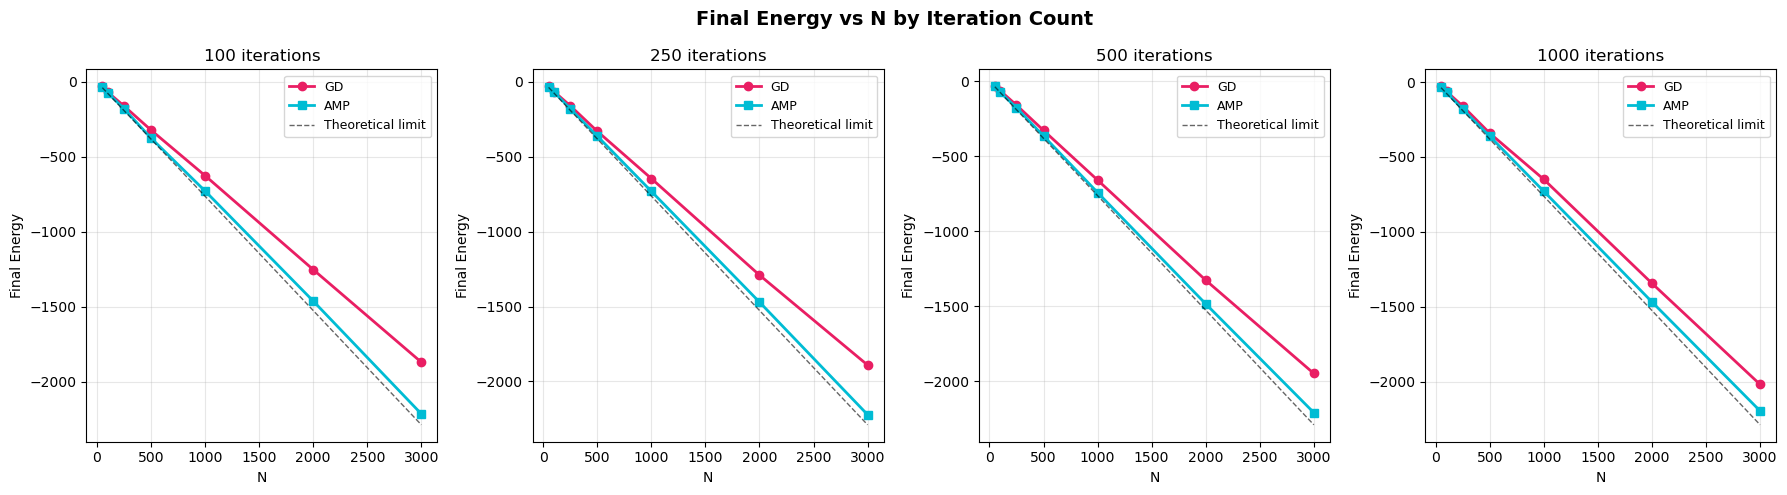

Saved fig1_energy_vs_N.png


In [ ]:
# ============================================================
# Figure 1: Final Energy vs N (per iteration count, both algos)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('Final Energy vs N by Iteration Count', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.plot(sub['N'], sub['gd_final_energy'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.plot(sub['N'], sub['amp_best_energy'],   's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.plot(sub['N'], sub['theoretical_limit'], 'k--', label='Theoretical limit', lw=1, alpha=0.6)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Final Energy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig1_energy_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_energy_vs_N.png')

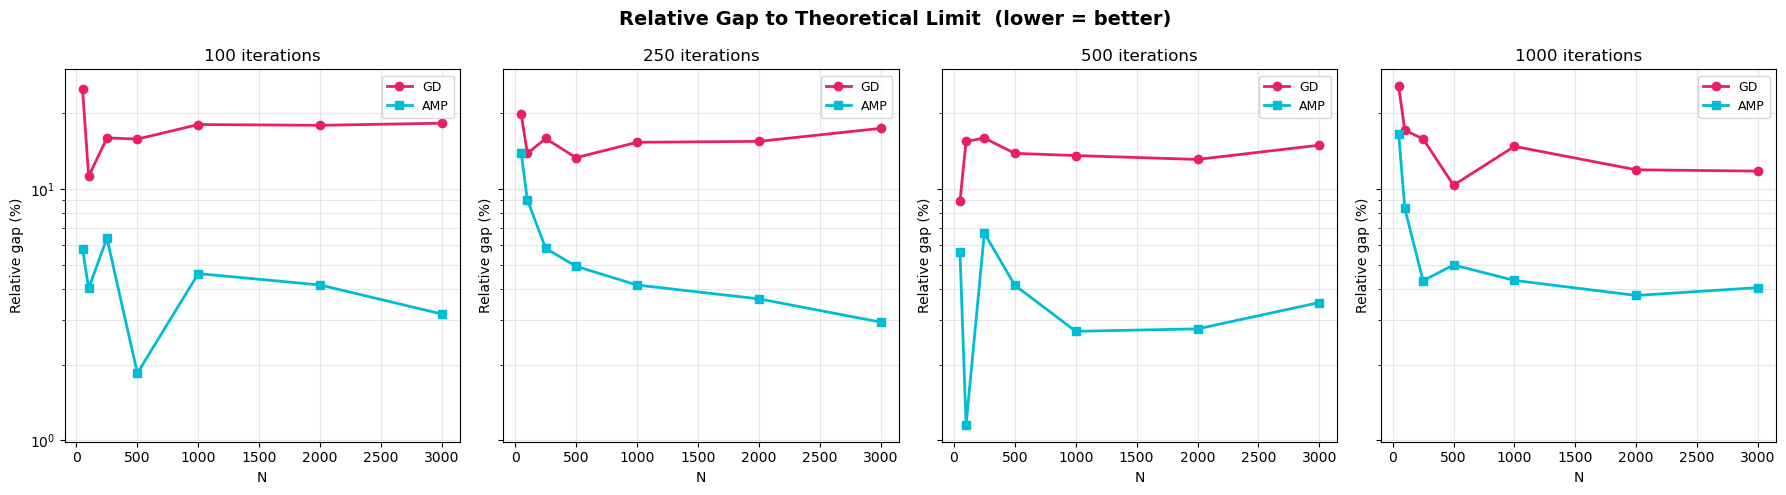

Saved fig2_rel_gap_vs_N.png


In [ ]:
# ============================================================
# Figure 2: Relative Gap to Theoretical Limit (% worse)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Relative Gap to Theoretical Limit  (lower = better)', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.semilogy(sub['N'], sub['gd_rel_gap_pct'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.semilogy(sub['N'], sub['amp_rel_gap_pct'],  's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Relative gap (%)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig2_rel_gap_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_rel_gap_vs_N.png')

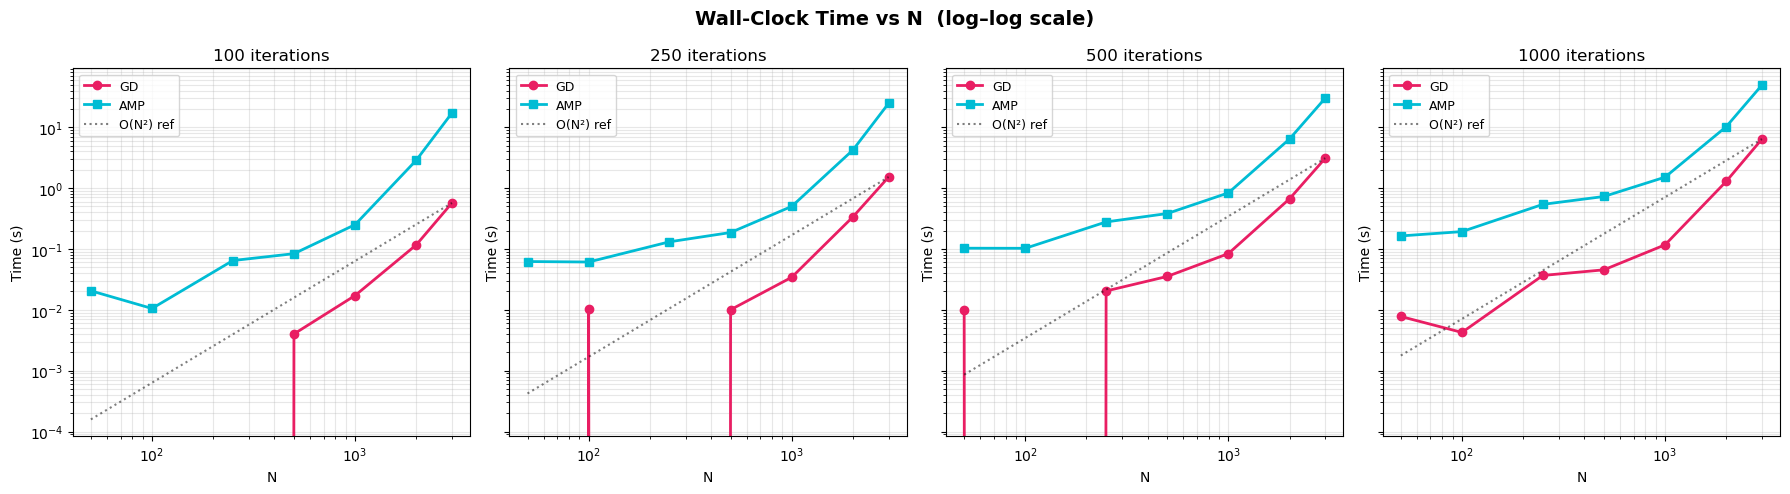

Saved fig3_time_vs_N.png


In [ ]:
# ============================================================
# Figure 3: Wall-Clock Time vs N (log-log)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Wall-Clock Time vs N  (log–log scale)', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.loglog(sub['N'], sub['gd_wall_sec'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.loglog(sub['N'], sub['amp_wall_sec'],  's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)

    # Reference O(N^2) line
    ns = np.array(sorted(sub['N']))
    ref = ns**2 / ns[-1]**2 * float(sub[sub['N']==ns[-1]]['gd_wall_sec'])
    ax.loglog(ns, ref, 'k:', alpha=0.5, label='O(N²) ref')

    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('Time (s)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig3_time_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_time_vs_N.png')

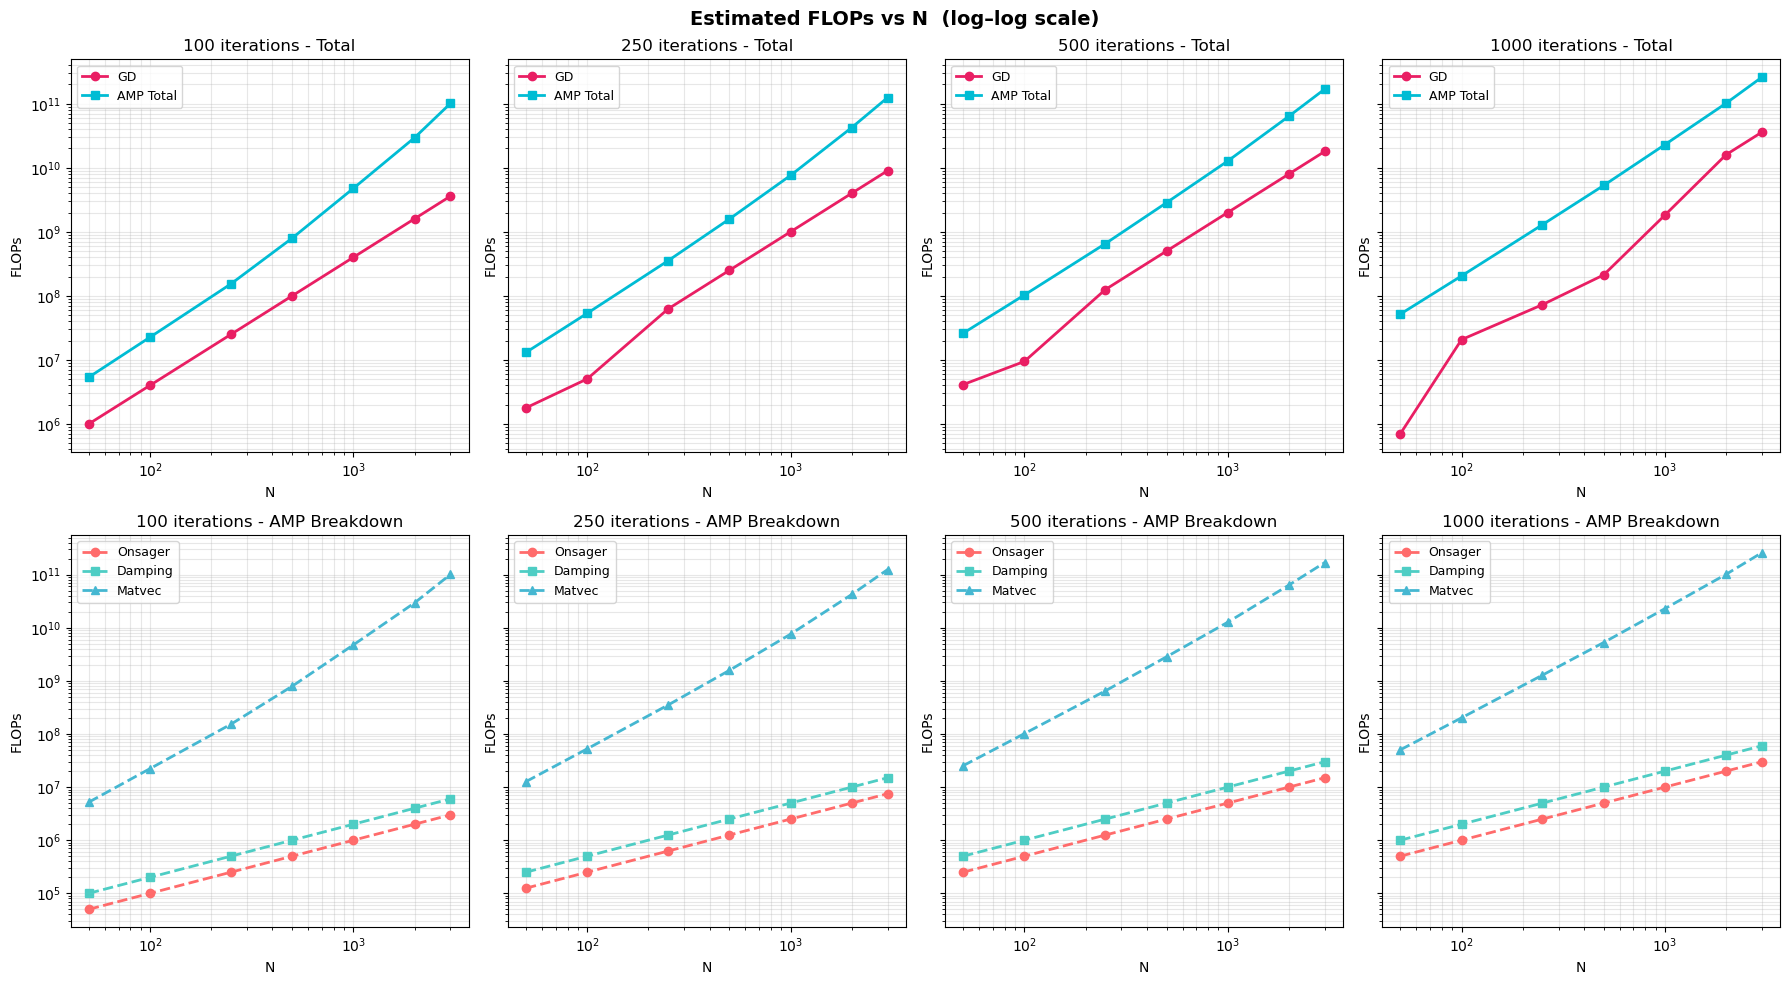

Saved fig4_flops_vs_N.png


In [ ]:
# ============================================================
# Figure 4: Estimated FLOPs vs N (log-log) - Total + Breakdown
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey='row')
fig.suptitle('Estimated FLOPs vs N  (log–log scale)', fontsize=14, fontweight='bold')

# Top row: Total FLOPs
for ax, iter_val in zip(axes[0], ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.loglog(sub['N'], sub['gd_flops'],         'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.loglog(sub['N'], sub['amp_total_flops'],   's-', color=ALGO_COLORS['AMP'], label='AMP Total', lw=2)
    ax.set_title(f'{iter_val} iterations - Total', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('FLOPs')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

# Bottom row: AMP breakdown
for ax, iter_val in zip(axes[1], ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.loglog(sub['N'], sub['amp_flops_onsager'],  'o--', color='#FF6B6B', label='Onsager',  lw=2)
    ax.loglog(sub['N'], sub['amp_flops_damping'],  's--', color='#4ECDC4', label='Damping',  lw=2)
    ax.loglog(sub['N'], sub['amp_flops_matvec'],   '^--', color='#45B7D1', label='Matvec',   lw=2)
    ax.set_title(f'{iter_val} iterations - AMP Breakdown', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('FLOPs')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig4_flops_vs_N.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_flops_vs_N.png')

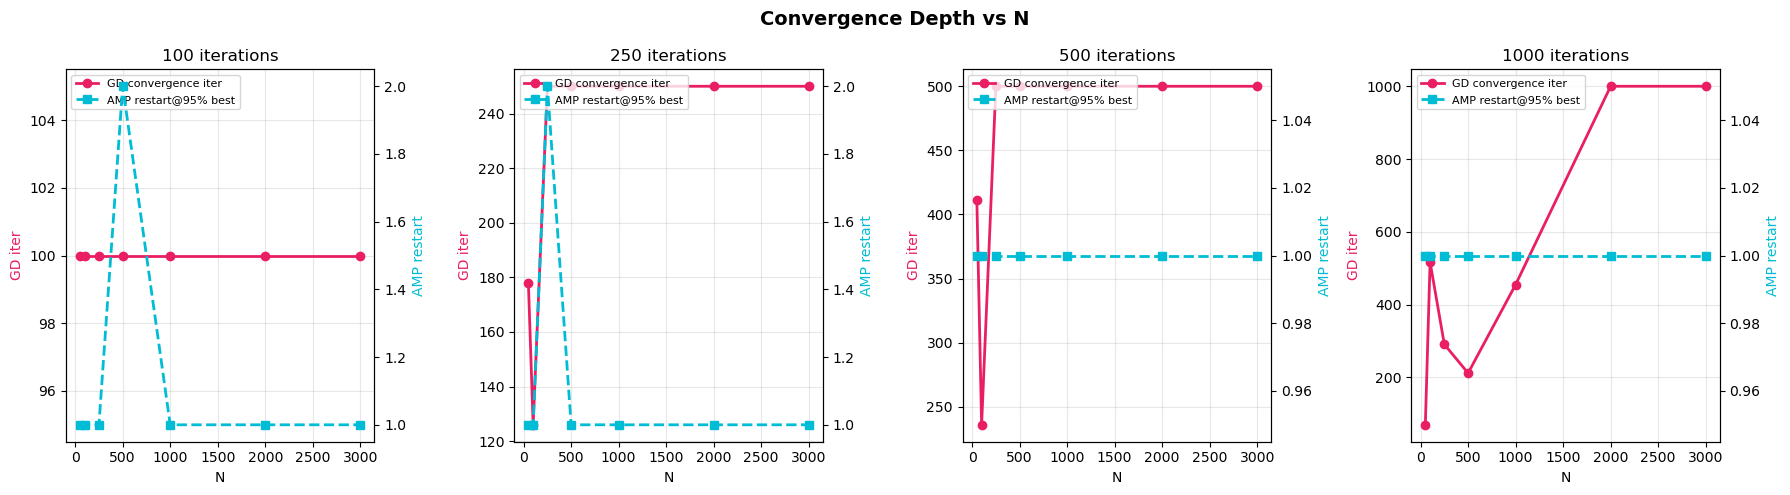

Saved fig5_convergence_depth.png


In [ ]:
# ============================================================
# Figure 5: Convergence Iteration (GD) and Restart (AMP) vs N
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('Convergence Depth vs N', fontsize=14, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax2 = ax.twinx()
    l1, = ax.plot(sub['N'],  sub['gd_convergence_iter'],  'o-', color=ALGO_COLORS['GD'],  lw=2, label='GD convergence iter')
    l2, = ax2.plot(sub['N'], sub['amp_conv_restart'],     's--', color=ALGO_COLORS['AMP'], lw=2, label='AMP restart@95% best')
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('GD iter', color=ALGO_COLORS['GD'])
    ax2.set_ylabel('AMP restart', color=ALGO_COLORS['AMP'])
    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig5_convergence_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_convergence_depth.png')

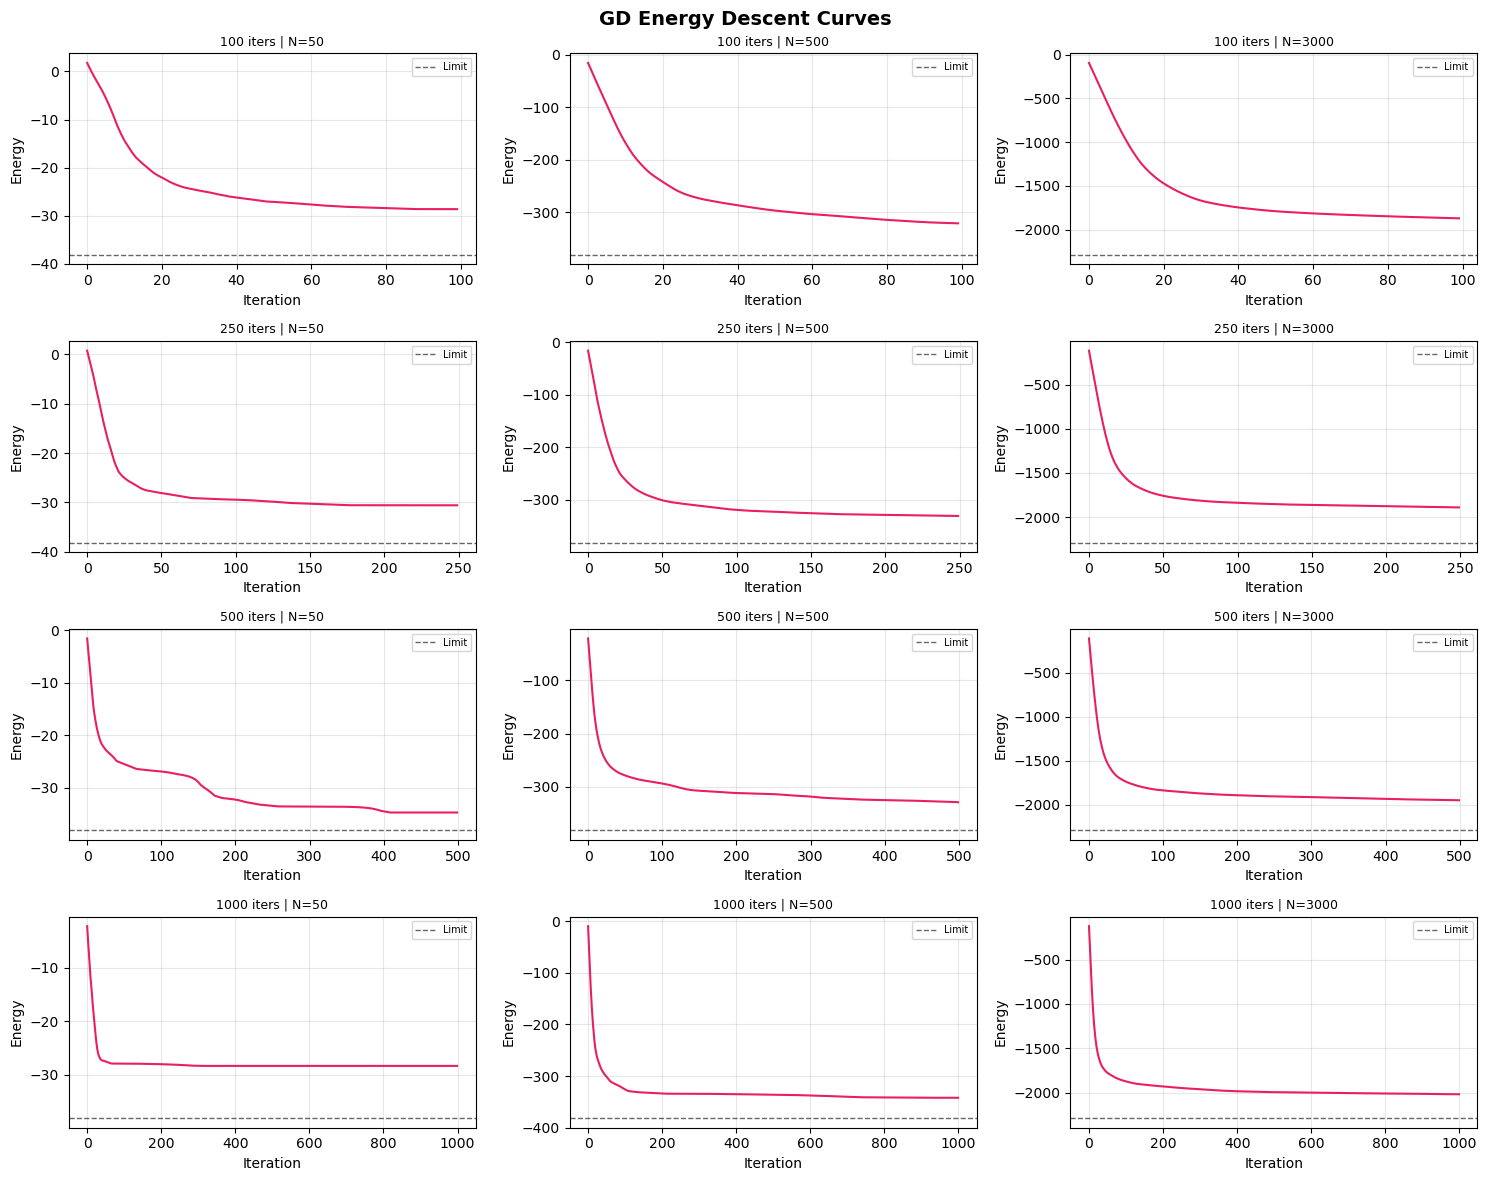

Saved fig6_gd_curves.png


In [ ]:
# ============================================================
# Figure 6: GD Energy Convergence Curves (selected N per iteration)
# ============================================================
sample_Ns = [N_VALUES[0], N_VALUES[len(N_VALUES)//2], N_VALUES[-1]]

fig, axes = plt.subplots(len(ITERATION_VALUES), len(sample_Ns), figsize=(15, 12))
fig.suptitle('GD Energy Descent Curves', fontsize=14, fontweight='bold')

for row, iter_val in enumerate(ITERATION_VALUES):
    for col, N in enumerate(sample_Ns):
        ax = axes[row, col]
        key = (iter_val, N)
        if key in convergence_curves:
            curve = convergence_curves[key]['gd_curve']
            limit = df[(df['iterations']==iter_val) & (df['N']==N)]['theoretical_limit'].values[0]
            ax.plot(curve, color=ALGO_COLORS['GD'], lw=1.5)
            ax.axhline(limit, color='k', ls='--', lw=1, alpha=0.6, label='Limit')
            ax.set_title(f'{iter_val} iters | N={N}', fontsize=9)
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Energy')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig6_gd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_gd_curves.png')

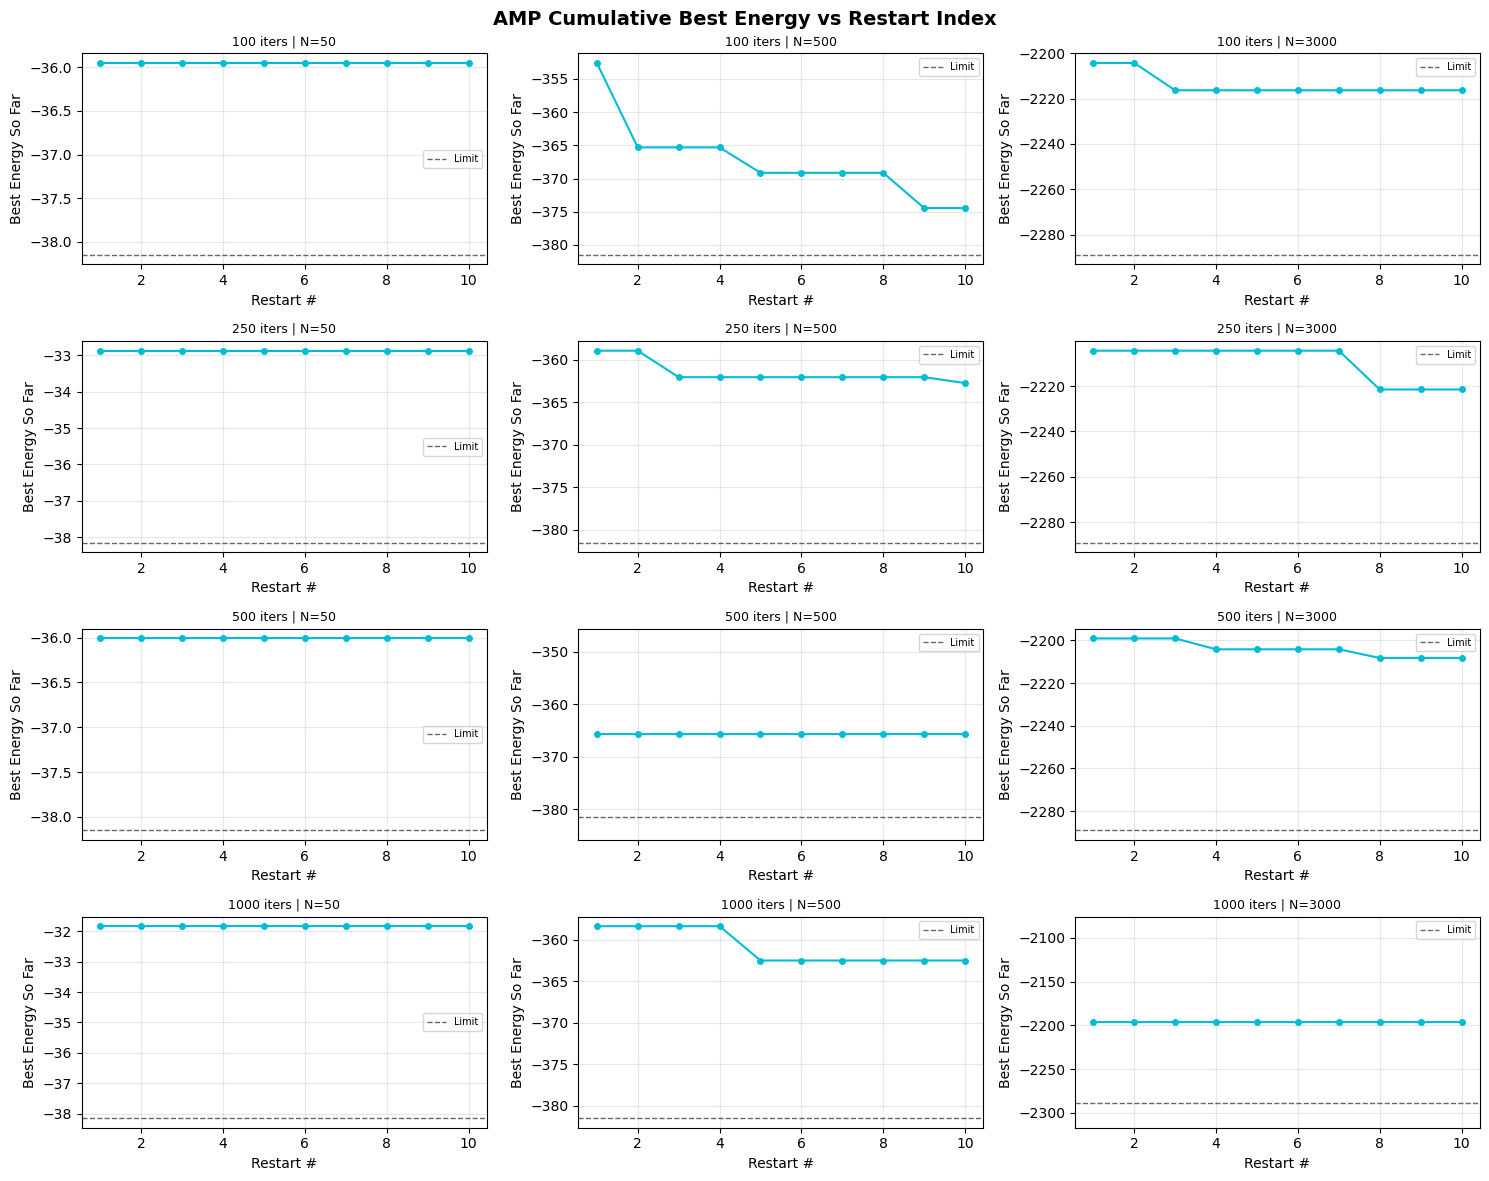

Saved fig7_amp_cumulative.png


In [ ]:
# ============================================================
# Figure 7: AMP Cumulative Best Energy Over Restarts
# ============================================================
fig, axes = plt.subplots(len(ITERATION_VALUES), len(sample_Ns), figsize=(15, 12))
fig.suptitle('AMP Cumulative Best Energy vs Restart Index', fontsize=14, fontweight='bold')

for row, iter_val in enumerate(ITERATION_VALUES):
    for col, N in enumerate(sample_Ns):
        ax = axes[row, col]
        key = (iter_val, N)
        if key in convergence_curves:
            cumulative = convergence_curves[key]['amp_cumulative_best']
            limit = df[(df['iterations']==iter_val) & (df['N']==N)]['theoretical_limit'].values[0]
            ax.plot(range(1, len(cumulative)+1), cumulative, color=ALGO_COLORS['AMP'], lw=1.5, marker='o', ms=4)
            ax.axhline(limit, color='k', ls='--', lw=1, alpha=0.6, label='Limit')
            ax.set_title(f'{iter_val} iters | N={N}', fontsize=9)
            ax.set_xlabel('Restart #')
            ax.set_ylabel('Best Energy So Far')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig7_amp_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig7_amp_cumulative.png')

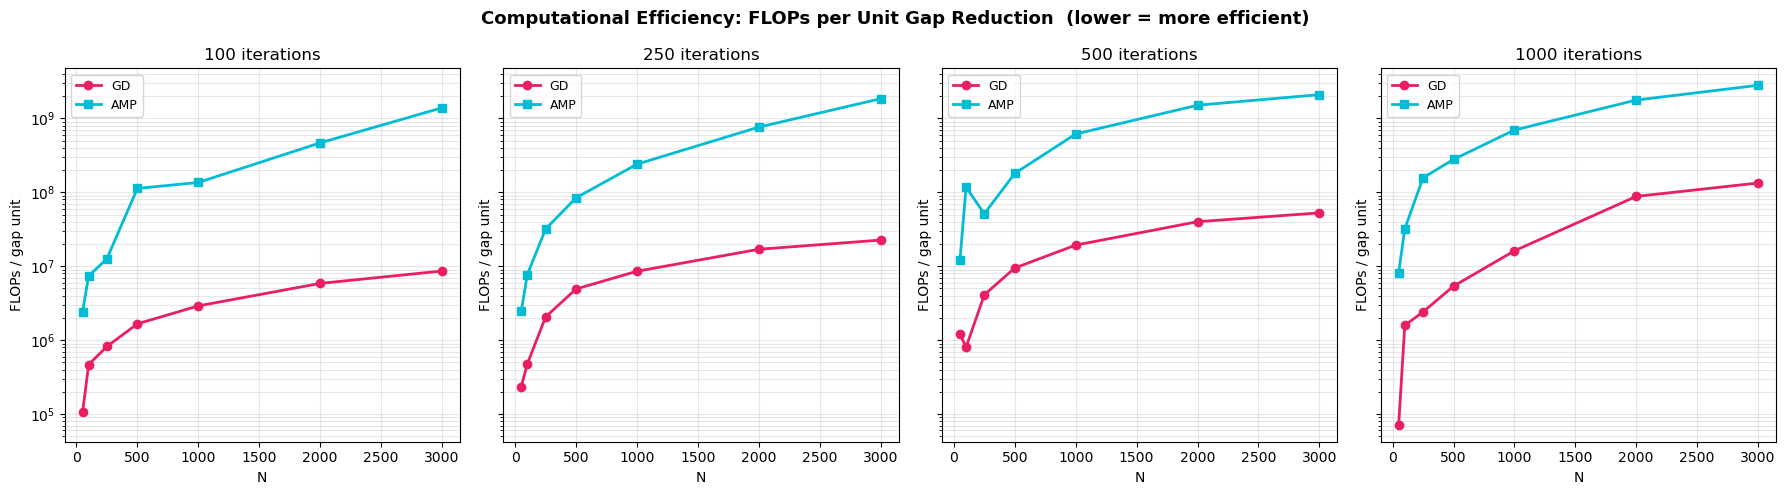

Saved fig8_flop_efficiency.png


In [ ]:
# ============================================================
# Figure 8: FLOPs per unit of Energy Improvement (efficiency)
# ============================================================
df['gd_flops_per_energy_unit']  = df['gd_flops']        / (df['gd_gap']  + 1e-6)
df['amp_flops_per_energy_unit'] = df['amp_total_flops'] / (df['amp_gap'] + 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle('Computational Efficiency: FLOPs per Unit Gap Reduction  (lower = more efficient)', fontsize=13, fontweight='bold')

for ax, iter_val in zip(axes, ITERATION_VALUES):
    sub = df[df['iterations'] == iter_val]
    ax.semilogy(sub['N'], sub['gd_flops_per_energy_unit'],  'o-', color=ALGO_COLORS['GD'],  label='GD',  lw=2)
    ax.semilogy(sub['N'], sub['amp_flops_per_energy_unit'], 's-', color=ALGO_COLORS['AMP'], label='AMP', lw=2)
    ax.set_title(f'{iter_val} iterations', fontsize=12)
    ax.set_xlabel('N')
    ax.set_ylabel('FLOPs / gap unit')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig8_flop_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig8_flop_efficiency.png')

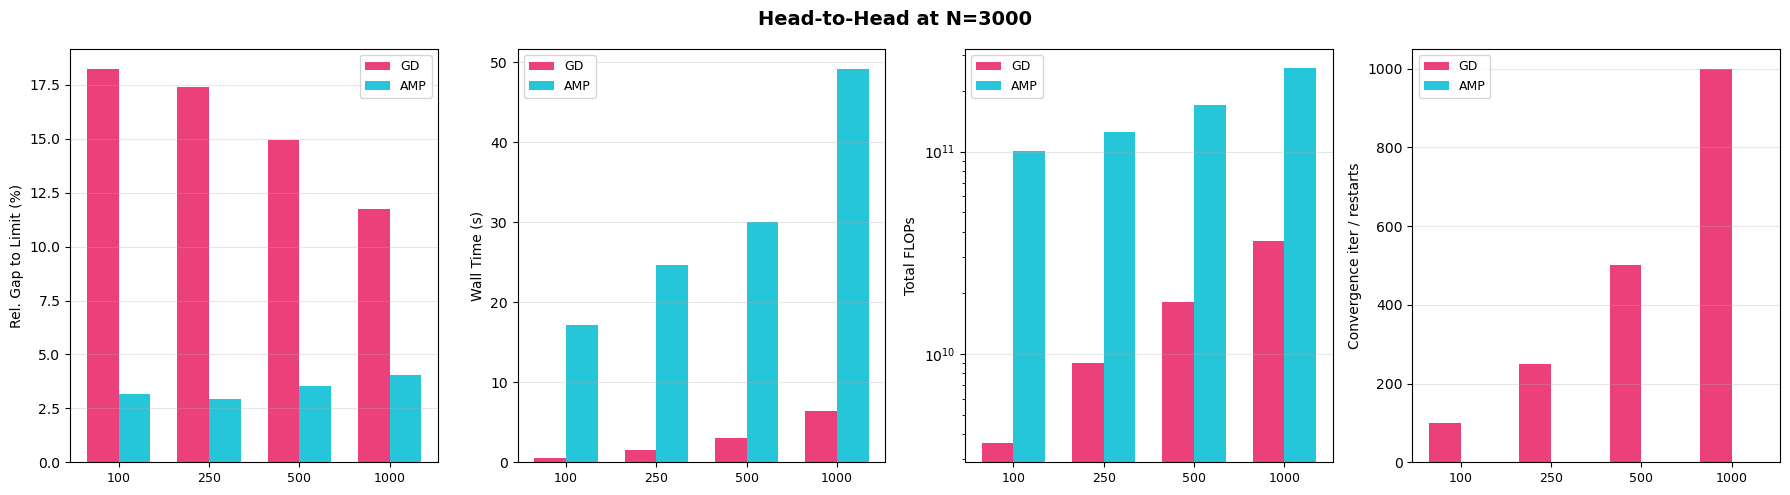

Saved fig9_head_to_head_bar.png


In [ ]:
# ============================================================
# Figure 9: Side-by-side bar chart of all metrics at largest N
# ============================================================
largest_N = max(N_VALUES)
sub_large = df[df['N'] == largest_N].copy()

metrics = [
    ('gd_rel_gap_pct',     'amp_rel_gap_pct',     'Rel. Gap to Limit (%)',         False),
    ('gd_wall_sec',        'amp_wall_sec',         'Wall Time (s)',                  False),
    ('gd_flops',           'amp_total_flops',      'Total FLOPs',                   True),
    ('gd_convergence_iter','amp_conv_restart',     'Convergence iter / restarts',   False),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
fig.suptitle(f'Head-to-Head at N={largest_N}', fontsize=14, fontweight='bold')
x = np.arange(len(ITERATION_VALUES))
width = 0.35

for ax, (gd_col, amp_col, ylabel, use_log) in zip(axes, metrics):
    gd_vals  = [float(sub_large[sub_large['iterations']==i][gd_col].values[0])  for i in ITERATION_VALUES]
    amp_vals = [float(sub_large[sub_large['iterations']==i][amp_col].values[0]) for i in ITERATION_VALUES]
    b1 = ax.bar(x - width/2, gd_vals,  width, label='GD',  color=ALGO_COLORS['GD'],  alpha=0.85)
    b2 = ax.bar(x + width/2, amp_vals, width, label='AMP', color=ALGO_COLORS['AMP'], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in ITERATION_VALUES], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if use_log:
        ax.set_yscale('log')

plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig9_head_to_head_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig9_head_to_head_bar.png')

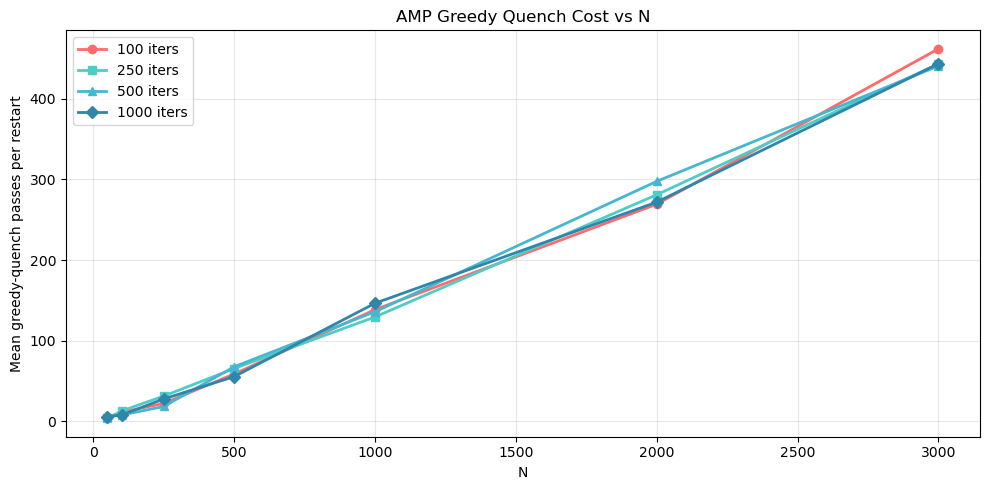

Saved fig10_quench_passes.png


In [ ]:
# ============================================================
# Figure 10: Mean Quench Passes (AMP post-processing cost) vs N
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for iter_val in ITERATION_VALUES:
    sub = df[df['iterations'] == iter_val]
    ax.plot(sub['N'], sub['amp_mean_quench_passes'], marker=ITER_MARKERS[iter_val],
            color=ITER_COLORS[iter_val], lw=2, label=f'{iter_val} iters')
ax.set_xlabel('N')
ax.set_ylabel('Mean greedy-quench passes per restart')
ax.set_title('AMP Greedy Quench Cost vs N')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Iters_vs_Graphs/fig10_quench_passes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig10_quench_passes.png')

## 8. Full Results Table

In [19]:
display_cols = [
    'N', 'iterations', 'theoretical_limit',
    'gd_final_energy', 'gd_rel_gap_pct', 'gd_wall_sec', 'gd_convergence_iter', 'gd_flops',
    'amp_best_energy', 'amp_rel_gap_pct', 'amp_wall_sec', 'amp_conv_restart',
    'amp_flops_onsager', 'amp_flops_damping', 'amp_flops_matvec', 'amp_total_flops',
    'winner', 'energy_improvement', 'speedup_gd_over_amp'
]

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
df[display_cols].sort_values(['iterations', 'N'])

,N,iterations,theoretical_limit,gd_final_energy,gd_rel_gap_pct,gd_wall_sec,gd_convergence_iter,gd_flops,amp_best_energy,amp_rel_gap_pct,amp_wall_sec,amp_conv_restart,amp_flops_onsager,amp_flops_damping,amp_flops_matvec,amp_total_flops,winner,energy_improvement,speedup_gd_over_amp
0,50,100,-38.1500,-28.6428,24.9205,0.0000,100,1000000,-35.9500,5.7667,0.0205,1,50000,100000,5210000,5360000,AMP,7.3072,20512580871.5820
4,100,100,-76.3000,-67.7459,11.2112,0.0000,100,4000000,-73.2328,4.0200,0.0105,1,100000,200000,22300000,22600000,AMP,5.4869,10508298873.9010
8,250,100,-190.7500,-160.3093,15.9584,0.0000,100,25000000,-178.6051,6.3669,0.0644,1,250000,500000,153000000,153750000,AMP,18.2958,64391136169.4340
12,500,100,-381.5000,-321.3117,15.7767,0.0040,100,100000000,-374.4506,1.8478,0.0835,2,500000,1000000,794500000,796000000,AMP,53.1388,20.8360
16,1000,100,-763.0000,-625.4277,18.0305,0.0172,100,400000000,-727.8920,4.6013,0.2503,1,1000000,2000000,4772000000,4775000000,AMP,102.4644,14.5880
20,2000,100,-1526.0000,-1252.8038,17.9028,0.1163,100,1600000000,-1462.7412,4.1454,2.8592,1,2000000,4000000,29536000000,29542000000,AMP,209.9374,24.5750
24,3000,100,-2289.0000,-1871.1646,18.2541,0.5696,100,3600000000,-2216.2982,3.1761,17.1334,1,3000000,6000000,101106000000,101115000000,AMP,345.1336,30.0820
1,50,250,-38.1500,-30.5908,19.8145,0.0000,178,1780000,-32.8742,13.8290,0.0621,1,125000,250000,12700000,13075000,AMP,2.2835,62057971954.3460
5,100,250,-76.3000,-65.7464,13.8318,0.0104,126,5040000,-69.3966,9.0477,0.0609,1,250000,500000,52600000,53350000,AMP,3.6503,5.8550
9,250,250,-190.7500,-160.4850,15.8663,0.0000,250,62500000,-179.6873,5.7996,0.1309,2,625000,1250000,351875000,353750000,AMP,19.2023,130897521972.6560
